# Mod6L5 Data Challenge — Interpreting SLR Output (Dec 2023 NYC Taxi)


**Format:** We Do (Instructor prompts) → You Do (Student work) → We Share (reflection)


**Goal:** Choose **one** dependent variable (**Y**) from the taxi dataset and build **three** simple linear regressions (each with a different single **X**) on **Dec 2023** rides. For each model, interpret the **coefficient**, **intercept**, **p‑value**, and **R‑squared** in plain business language. Then decide which model is “better” *for decision‑making* and why.


> **Reminder:** No train/test split or advanced metrics today. We focus on reading `.summary()` and communicating results.

## Instructor Section (10 mins)

**Follow these steps/considerations as you work**


1) **Pick a useful Y.** Which outcome would someone actually act on?  Who is the stakeholder for your Y?

*Avoid constructing Y that bakes in your X (e.g., avoid using `fare_amount` as X when Y = `total_amount` which already includes fare).*


2) **Choose three X’s** you can know at decision time, and that plausibly relate to Y. 

*You may engineer a feature to use in the model if you like*

*Note:  SLR needs numeric only inputs so variables like `PULocationID` can't be used (categorical → not for SLR today unless you transform; stick to numeric X for this exercise)*


3) **Interpretation lenses:**
- **Units:** Always state slope in units (e.g., “per mile”, “per minute”).
- **p‑value:** Does evidence suggest the slope ≠ 0?
- **R²:** How much of Y’s variation is captured by this X? Does that help the decision?
- **Intercept:** Is X=0 meaningful? If not, say it’s a math anchor.
- **Plausibility:** Does the direction/size make sense (e.g., longer trip → higher fare)?


4) **Better ≠ only higher R².** Weigh **interpretability**, **actionability**, and **evidence** (p‑value, CI) alongside R².

## YOU DO (40 mins)

### Step 1: Read in the Data & Choose your **Y** (dependent variable)

Pick one from the 2023_Yellow_Taxi_Trip_Data_20251015 csv file  

### Step 2: Propose three candidate **X** predictors (numeric)

Pick three different X columns that are **numeric** and **known at decision time**.

### Step 3: Fit three one‑variable models with the SAME Y and different Xs

### Step 4: Visual check for the “best” model candidate

Pick the model you currently prefer (based on business sense + evidence).
- Create a scatter of X vs. Y with the fitted line.

### Step 5: Interpret Each Model (write in plain English)
Fill the three blocks below. Use **units** and **percentage points (pp)** where relevant.

- **Slope (β₁):** “For each +1 unit of X, Y changes by …”
- **Intercept (β₀):** meaningful or just a math anchor? Explain.
- **p‑value:** is there evidence the slope ≠ 0?
- **R²:** how much variation does this X explain?
- **Judgment:** is the effect size **practically** meaningful (tie to business)?

In [95]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/Marcy_Student/DA2025_Lectures/DA2025_Lectures/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory=False)

In [ ]:
# converting tip_amount to float
df['tip_amount'] = pd.to_numeric(df['tip_amount'].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True), errors='coerce')

# converting passenger count
df['passenger_count'] = pd.to_numeric(df['passenger_count'].astype(str).str.strip().replace(to_replace='nan', value=0, regex=True), errors='coerce')
df['passenger_count'] = df['passenger_count'].astype(int)
# pickup hour
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df.dtypes

/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_72597/1182776705.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])


VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime            object
passenger_count                   int64
trip_distance                    object
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                      object
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                     object
congestion_surcharge            float64
airport_fee                     float64
pickup_hour                       int32
dtype: object

In [102]:
# Clean data some and add a new column called 'tip_pct' as the target
df = df[(df['tip_amount'] > 0) & (df['passenger_count'] > 0) ]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)

In [103]:
list_col = ['tip_amount', 'passenger_count']
for _ in list_col:
    Q1 = df[_].quantile(0.25)
    Q3 = df[_].quantile(0.95)
    IQR = Q3 - Q1
    df = df[(df[_] >= Q1 - 1.5*IQR) & (df[_] <= Q3 + 1.5*IQR)]

In [104]:
X = sm.add_constant(df[['passenger_count']])
y = df['tip_amount']
model = sm.OLS(y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             tip_amount   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5847.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:08:24   Log-Likelihood:            -6.5013e+06
No. Observations:             2367082   AIC:                         1.300e+07
Df Residuals:                 2367080   BIC:                         1.300e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.3639      0.005    947.658      0.000       4.355       4.373
passenger_count     0.2114      0.003     76.466      0.000       0.206       0.217
==============================================================================
Omnibus:                  1117252.147   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5762372.255
Skew:                           2.310   Prob(JB):                         0.00
Kurtosis:                       9.089   Cond. No.                         4.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_72597/3588242125.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='passenger_count', y='tip_amount', data=df, color='red', ci=None)


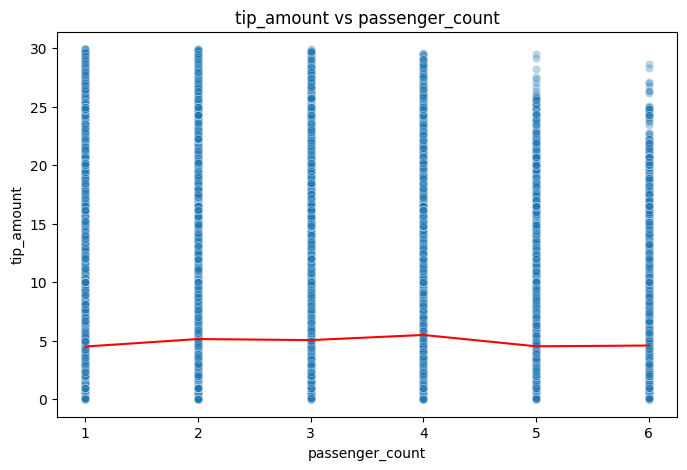

In [113]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='passenger_count', y='tip_amount', data=df, alpha=0.3)
sns.lineplot(x='passenger_count', y='tip_amount', data=df, color='red', ci=None)
plt.title('tip_amount vs passenger_count')
plt.xlabel('passenger_count')
plt.ylabel('tip_amount')
plt.show()

### Model A — Y = {{tip_amount}} ~ X1 = {{passenger count}}
- Slope (β₁): 0.2114
- Intercept (β₀): 4.3639
- p‑value (slope): 0.000
- 95% CI for slope: [0.206	0.217]
- R²: 0.002
- Business readout (units): For every aditional passenger there is on average 21c greater tip, starting at $4.36.
- One limitation: There is a capacity limit for passengers in a single car.

In [106]:
X = sm.add_constant(df[['pickup_hour']])
y = df['tip_amount']
model = sm.OLS(y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             tip_amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     871.8
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          1.47e-191
Time:                        19:08:38   Log-Likelihood:            -6.5038e+06
No. Observations:             2367082   AIC:                         1.301e+07
Df Residuals:                 2367080   BIC:                         1.301e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.4826      0.007    684.064      0.000       4.470       4.495
pickup_hour     0.0124      0.000     29.525      0.000       0.012       0.013
==============================================================================
Omnibus:                  1123151.953   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5836851.654
Skew:                           2.322   Prob(JB):                         0.00
Kurtosis:                       9.133   Cond. No.                         41.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_72597/702145697.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='pickup_hour', y='tip_amount', data=df, color='red', ci=None)


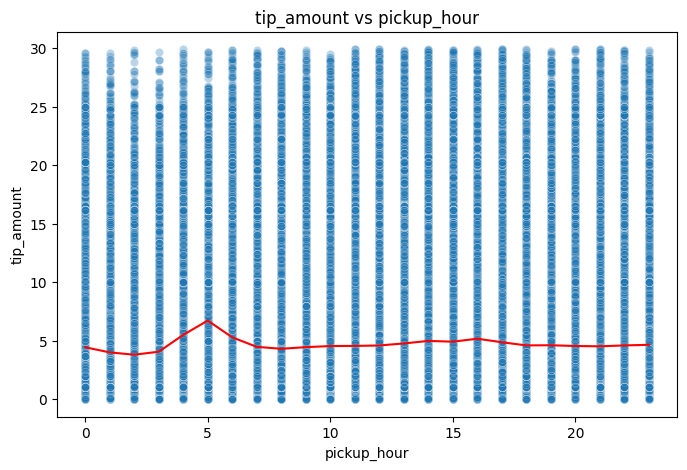

In [109]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='pickup_hour', y='tip_amount', data=df, alpha=0.3)
sns.lineplot(x='pickup_hour', y='tip_amount', data=df, color='red', ci=None)
plt.title('tip_amount vs pickup_hour')
plt.xlabel('pickup_hour')
plt.ylabel('tip_amount')
plt.show()

### Model B — Y = {{tip_amount}} ~ X2 = {{pick up time}}
- Slope (β₁): 0.0124
- Intercept (β₀): 4.4826
- p‑value (slope): 0.000
- 95% CI for slope: [0.012	0.013]
- R²: 0.000
- Business readout (units): For every additional hour tip amount increases 1c with the starting tip of $4.48.
- One limitation: Measuring hours is more of an aggregate showing seasonality rather than a prediction.

In [110]:
X = sm.add_constant(df[['payment_type']])
y = df['tip_amount']
model = sm.OLS(y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             tip_amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     36.06
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           1.91e-09
Time:                        19:11:04   Log-Likelihood:            -6.5042e+06
No. Observations:             2367082   AIC:                         1.301e+07
Df Residuals:                 2367080   BIC:                         1.301e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.2948      0.061     70.197      0.000       4.175       4.415
payment_type     0.3669      0.061      6.005      0.000       0.247       0.487
==============================================================================
Omnibus:                  1121089.900   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5808126.799
Skew:                           2.318   Prob(JB):                         0.00
Kurtosis:                       9.115   Cond. No.                         49.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/7n/rj4gbkk13_1f9n1qf54j12gh0000gp/T/ipykernel_72597/2540163331.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='payment_type', y='tip_amount', data=df, color='red', ci=None)


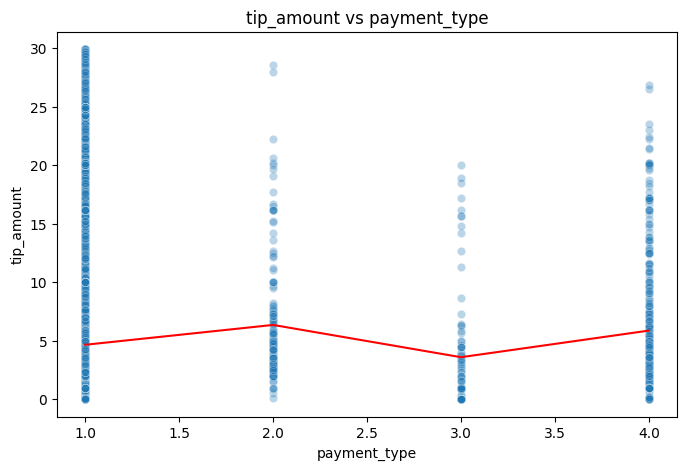

In [112]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='payment_type', y='tip_amount', data=df, alpha=0.3)
sns.lineplot(x='payment_type', y='tip_amount', data=df, color='red', ci=None)
plt.title('tip_amount vs payment_type')
plt.xlabel('payment_type')
plt.ylabel('tip_amount')
plt.show()

### Model C — Y = {{tip_amount}} ~ X3 = {{payment type}}
- Slope (β₁): 0.3669
- Intercept (β₀): 4.2948
- p‑value (slope): 0.000
- 95% CI for slope: [0.247	0.487]
- R²: 0.000
- Business readout (units): If payment type is a credit card on average tip amount is 36c more than if payed with cash, base tip starts at $4.29.
- One limitation: Difficult to interpret model based on X being a categorical variable. 

## We Share (10 mins) — Reflection & Decision (write 1-2 short paragraphs)

1) **Which model is “better” for a stakeholder decision and why?**
- Weigh **evidence** (p‑value, CI), **explanatory power** (R²), **interpretability**, and **business impact** (units, MDE if relevant).
2) **What would you do next week to strengthen trust in this model?**
- (Preview) time‑based validation, hold‑out testing, segment checks, adding more plausible X’s, checking assumptions.

Reflection 

Tip amound by pick up hour I belive is the most insight full and actionable to stakeholders. It tells the clearest story of predicting which hours preform the best, with a slight peak at 5am in the morning. It also has the lowest varience for it's 95% confidence interval. My next steps in developing this model would be to add more plausible X's. While pick up time tells the most satisfying story and has an exteamly low P-value, its low R² suggest that other factors contribute more hevily to the increase in tip amount.